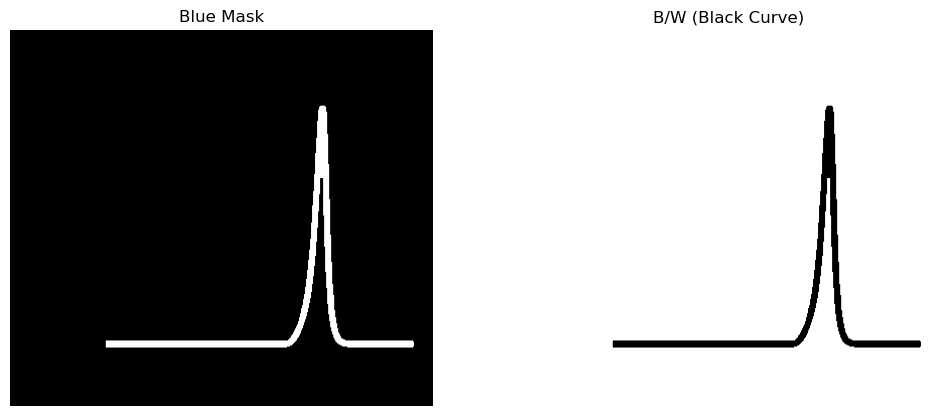

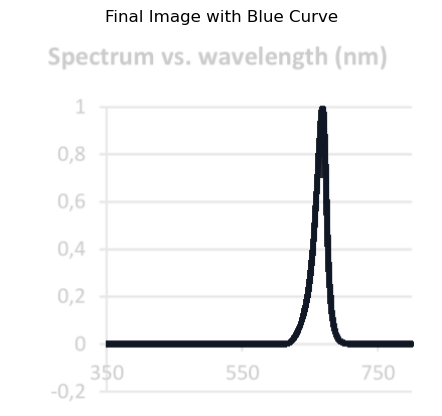

In [54]:
import numpy
import cv2
from matplotlib import pyplot

# image_path = "test.png"
image_path = "660nm_red_LED.png"

img = cv2.imread(image_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Blue range in HSV (tune if needed)
lower_blue = numpy.array([90, 50, 50], dtype=numpy.uint8)
upper_blue = numpy.array([140, 255, 255], dtype=numpy.uint8)

# Mask blue regions
blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

# Optional cleanup
kernel = numpy.ones((3, 3), numpy.uint8)
blue_mask = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel, iterations=1)
blue_mask = cv2.morphologyEx(blue_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

# black mask
kernel = numpy.ones((3, 3), numpy.uint8)
black_mask = cv2.inRange(hsv, numpy.array([0, 0, 0], dtype=numpy.uint8), numpy.array([180, 255, 50], dtype=numpy.uint8))
black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_OPEN, kernel, iterations=1)

# Black curve on white background
bw_curve = 255 - blue_mask

pyplot.figure(figsize=(12, 5))
pyplot.subplot(1, 2, 1)
pyplot.title("Blue Mask")
pyplot.imshow(blue_mask, cmap="gray")
pyplot.axis("off")

pyplot.subplot(1, 2, 2)
pyplot.title("B/W (Black Curve)")
pyplot.imshow(bw_curve, cmap="gray")
pyplot.axis("off")
pyplot.show()

bw_curve_bgr = cv2.cvtColor(bw_curve, cv2.COLOR_GRAY2BGR)
final_image = cv2.addWeighted(img, 0.2, bw_curve_bgr, 0.8, 0)
# final_image = bw_curve_bgr.copy()
# gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# _, bw_binary = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# final_image = cv2.cvtColor(bw_binary, cv2.COLOR_GRAY2BGR)

pyplot.figure(figsize=(12, 5))
pyplot.subplot(1, 2, 1)
pyplot.title("Final Image with Blue Curve")
pyplot.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
pyplot.axis("off")
pyplot.show()

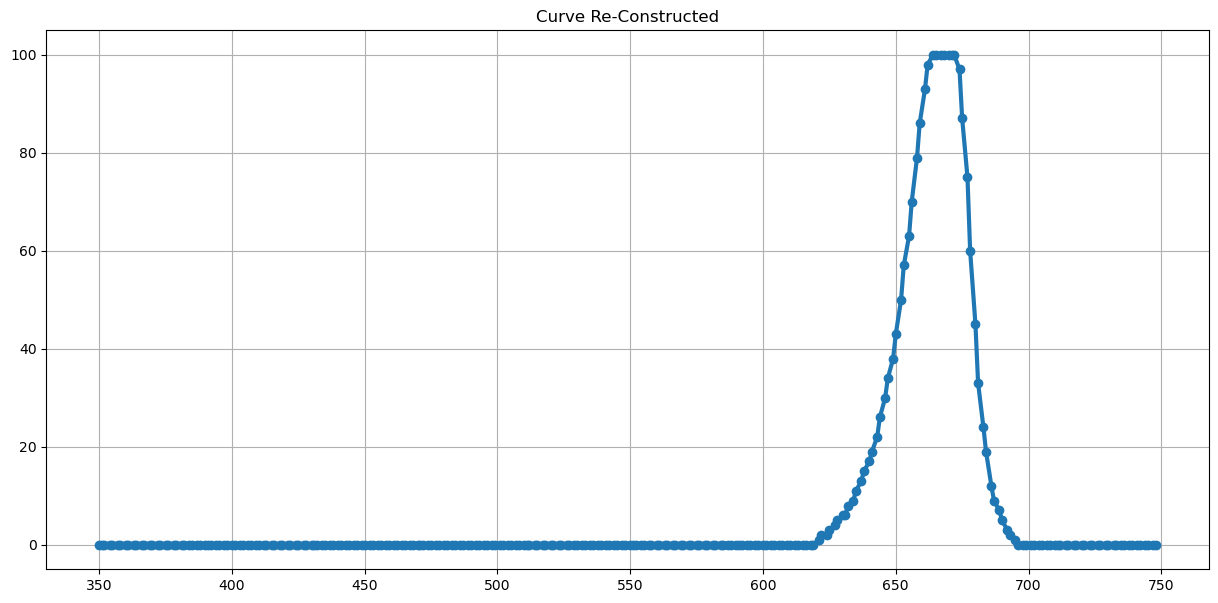

In [55]:
# Source - https://stackoverflow.com/a/78914093
# Posted by Barış Aktaş, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-01, License - CC BY-SA 4.0

import numpy
import skimage
import cv2
from matplotlib import pyplot

#Function to take difference between two consecutive points
now = 0
def differentiator(variable):
    global now
    before = now
    now = variable
    return now-before

#Function to find rising edges from profile data
def findRisingEdges(profile, min_height=1, max_height=255, min_width=1, max_width=255,smoothing=10):
    profile_diff = [differentiator(p) for p in profile]
    if smoothing:
        profile_diff = [pd if abs(pd)>smoothing else 0 for pd in profile_diff]
    rising_edges = []
    
    i=0
    while i < len(profile_diff): # do not check the last point
        edge_start,edge_end = None,None
        diff = profile_diff[i]

        #Search positive derivative for rising edge
        if diff > 0:
            edge_start = i-1 if i>1 else i

            #Find where the edge ends by searching non-positive derivative
            if i == (len(profile_diff)-1):# if its the last point then it is edge end
                edge_end = i
                i = i + 1
            else:
                while profile_diff[i+1]>0:
                    i = i + 1
                    if i == (len(profile_diff)-1):
                        break
                edge_end = i
                i = i + 1

            edge_width = edge_end - edge_start
            edge_height = profile[edge_end] - profile[edge_start]

            if edge_width >= min_width and edge_width <= max_width and edge_height >= min_height and edge_height <= max_height:
                rising_edges.append([edge_start,edge_end,edge_width,edge_height])
        else:
            i = i + 1

    return rising_edges

#Function to find falling edges from profile data
def findFallingEdges(profile, min_height=1, max_height=255, min_width=1, max_width=255,smoothing=10):
    profile_diff = [differentiator(p) for p in profile]
    if smoothing:
        profile_diff = [pd if abs(pd)>smoothing else 0 for pd in profile_diff]

    falling_edges = []
    i=0
    while i < len(profile_diff): # do not check the last point
        edge_start,edge_end = None,None
        diff = profile_diff[i]
        #Search negative derivative for rising edge
        if diff < 0:
            edge_start = i-1 if i>1 else i

            #Find where the edge ends by searching non-negative derivative
            if i == (len(profile_diff)-1):# if its the last point then it is edge end
                edge_end = i
                i = i + 1
            else:
                while profile_diff[i+1]<0:
                    i = i + 1
                    if i == (len(profile_diff)-1):
                        break
                edge_end = i
                i = i + 1
            
            edge_width = edge_end - edge_start
            edge_height = abs(profile[edge_end] - profile[edge_start])

            if edge_width >= min_width and edge_width <= max_width and edge_height >= min_height and edge_height <= max_height:
                falling_edges.append([edge_start,edge_end,edge_width,edge_height])
        else:
            i = i + 1

    return falling_edges

#Function to find sinks on the profile by looking for falling edges followed by rising edges
def findSinks(profile, min_width=3, min_depth=50, smoothing=10,
                min_fe_height=1, max_fe_height=255, min_fe_width=1, max_fe_width=255, 
                min_re_height=1, max_re_height=255, min_re_width=1, max_re_width=255):
    
    rEdges = findRisingEdges(profile, min_height=min_fe_height, max_height=max_fe_height, min_width=min_fe_width, max_width=max_fe_width,smoothing=smoothing)
    fEdges = findFallingEdges(profile, min_height=min_re_height, max_height=max_re_height, min_width=min_re_width, max_width=max_re_width,smoothing=smoothing)

    sinks = []
    for rising_edge in rEdges:
        rising_edge_start,rising_edge_end,reWidth,reHeight = rising_edge 
        falling_edge_starts = [f[0] for f in fEdges]

        #Find all the sinks
        for y in reversed(range(0,rising_edge_end)):

            if y in falling_edge_starts:
                falling_edge_start,falling_edge_end,feWidth,feHeight = fEdges[falling_edge_starts.index(y)]
                
                sinkwidth = rising_edge_end-falling_edge_start+1
                depth = (feHeight+reHeight)//2
                if sinkwidth>=min_width and depth>=min_depth:
                    sinks.append([falling_edge_start,rising_edge_end,depth])
                break
    return sinks

#Function to find the curve from the image 
def extractCurve(src_image, profile_interval=5):
    #Read the image
    h,w,c = src_image.shape
    gray = cv2.cvtColor(src_image,cv2.COLOR_BGR2GRAY)

    #Scan the image through it's width(x-axis) get profile line extract curve's points
    last_y_level = 0 #this will always contain the latest curve point
    curve_points = []
    for xi in range(w//profile_interval):
        #Draw the profile on image
        cv2.line(graph,(xi*profile_interval,0),(xi*profile_interval,h),(255,0,0),1)

        #Get the profile
        profile = skimage.measure.profile_line(gray, (0,xi*profile_interval), (h,xi*profile_interval), linewidth=1, mode='constant') #Take the profile line

        #Find all the sinks in the profile data one of thesee points belongs to the curve
        sinks = findSinks(profile,smoothing=10,min_fe_height=150,min_re_height=150)

        if len(sinks)==0:   #If no sink no curve point
            pass
        
        elif len(sinks)==1: #If 1 sink it is the curve point
            start,end,depth = sinks[0]
            # pX,pY = xi*profile_interval,(start+end)//2
            pX,pY = xi*profile_interval,start
            cv2.circle(src_image,(pX,pY),4,(0,0,255),-1)
            curve_points.append([pX,pY])
            last_y_level = pY
        
        else:   #If multiple sinks choose the one closest to last curve point
            closest = sinks[0]
            start,end,depth = closest
            min_y_dist = abs((start+end)//2 - last_y_level)
            sinks.pop(0)
            for sink in sinks:
                start,end,depth = sink
                y_dist = abs((start+end)//2 - last_y_level)
                if y_dist < min_y_dist:
                    min_y_dist = y_dist
                    closest = sink

            start,end,depth = closest
            # pX,pY = xi*profile_interval,(start+end)//2
            pX,pY = xi*profile_interval,start
            cv2.circle(src_image,(pX,pY),4,(0,0,255),-1)
            curve_points.append([pX,pY])
            last_y_level = pY

        cv2.imshow('graph',graph)
        cv2.waitKey(1)
        # pyplot.plot(profile,'o-')
        # pyplot.show()

    return curve_points

#Read the image
# image = cv2.imread('test2.png')
image = final_image.copy()

#Choose the region of interest including excat boundries the graph
rx,ry,rw,rh = cv2.selectROI('Select The Complete and Exact Boundaries of Graph',image)
graph = image[ry:ry+rh,rx:rx+rw]
cv2.destroyWindow('Select The Complete and Exact Boundaries of Graph')

#Enter the min and max values from the source graph here
y_min,y_max = 0, 100
x_min,x_max = 350, 750

#Extract the curve points on the image
curve = extractCurve(graph, profile_interval=1)
curve_ymax = max([c[1] for c in curve])
curve_ymin = min([c[1] for c in curve])

#Map curve (x,y) pixel points to actual data points from graph
# curve_normalized = [[int((cx/rw)*(x_max-x_min)+x_min),int((1-cy/rh)*(y_max-y_min)+y_min)] for cx,cy in curve]
curve_normalized = [[int((cx/rw)*(x_max-x_min)+x_min),int((1-(cy-curve_ymin)/(curve_ymax-curve_ymin))*(y_max-y_min)+y_min)] for cx,cy in curve]
curve_normalized = numpy.array(curve_normalized)

#Plot the newly constructed curve
pyplot.figure(figsize=(15,7))
pyplot.plot(curve_normalized[:,0],curve_normalized[:,1],'o-',linewidth=3)
pyplot.title('Curve Re-Constructed')
pyplot.grid(True)
pyplot.show()


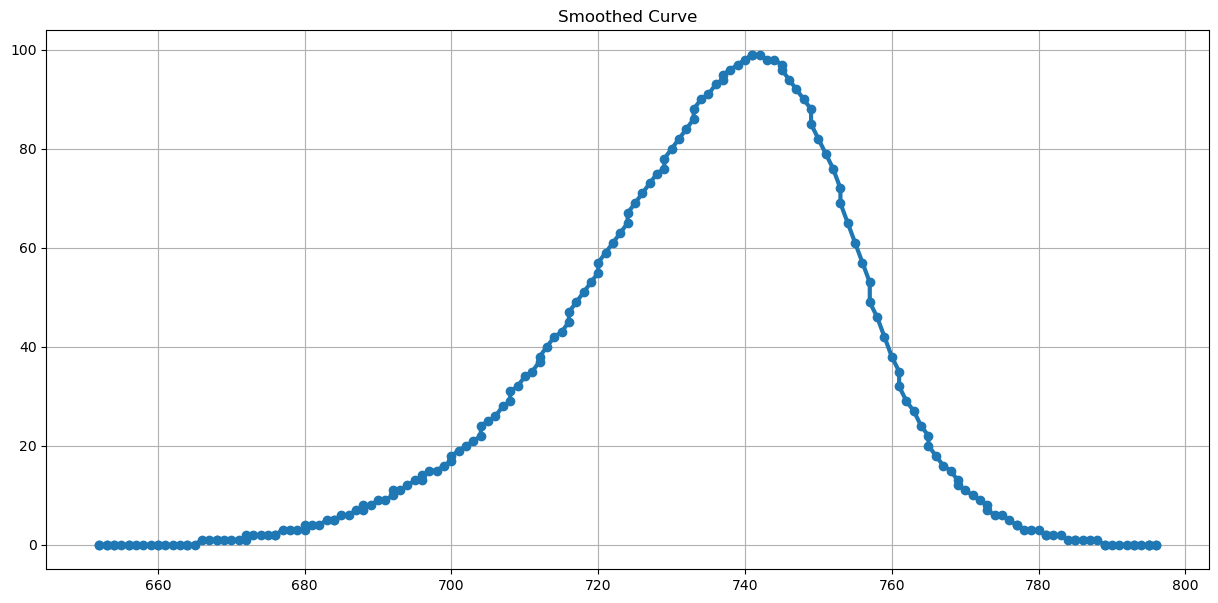

In [31]:
# apply a moving average filter to smooth the curve
window_size = 10
curve_smoothed = numpy.copy(curve_normalized)
for i in range(len(curve_normalized)):
    start = max(0, i - window_size // 2)
    end = min(len(curve_normalized), i + window_size // 2 + 1)
    curve_smoothed[i] = numpy.mean(curve_normalized[start:end], axis=0)

#plot the smoothed curve
pyplot.figure(figsize=(15,7))
pyplot.plot(curve_smoothed[:,0],curve_smoothed[:,1],'o-',linewidth
=3)
pyplot.title('Smoothed Curve')
pyplot.grid(True)
pyplot.show()

In [ ]:
# store curve as dataframe
import pandas as pd

curve_df = pd.DataFrame(curve_normalized, columns=['wavelength [nm]', 'relative intensity [%]'])

curve_df.to_csv(image_path.split('.')[0] + '.csv', index=False)

# Spectrum optimization

In [ ]:
import pandas as pd
import numpy
import skimage
import cv2
from matplotlib import pyplot
import numpy
import cv2
from matplotlib import pyplot

# import data from csv
LED_spectra = {}
optimal_power_scaling = {}

########################### Solar spectrum data processing
AM1_5G_path = r""

if not AM1_5G_path:
    raise ValueError("Please provide the path to the AM1.5G spectrum file.")

df_AM1_5G = pd.read_excel(AM1_5G_path, skiprows=1, names=["wavelength [nm]", "Etr [W/m2]", "global tilt [W/m2]", "direct+circumsolar [W/m2]"], sheet_name=0)

# Group by every 2 rows and sum, keeping the first wavelength value
Solar_spectrum_binned = pd.DataFrame()
Solar_spectrum_binned = df_AM1_5G.iloc[::1].reset_index(drop=True).copy()
Solar_spectrum_binned['Etr [W/m2]'] += df_AM1_5G.iloc[0::1]['Etr [W/m2]'].values
Solar_spectrum_binned['global tilt [W/m2]'] += df_AM1_5G.iloc[0::1]['global tilt [W/m2]'].values
Solar_spectrum_binned['direct+circumsolar [W/m2]'] += df_AM1_5G.iloc[0::1]['direct+circumsolar [W/m2]'].values

for col in ['Etr [W/m2]', 'global tilt [W/m2]', 'direct+circumsolar [W/m2]']:
    Solar_spectrum_binned[col] = Solar_spectrum_binned[col]/2

lambda_min, lambda_max = 400, 800

solar_spectrum_filtered = Solar_spectrum_binned [(Solar_spectrum_binned['wavelength [nm]'] >= lambda_min) & (Solar_spectrum_binned['wavelength [nm]'] <= lambda_max)].reset_index(drop=True)

df_AM1_5G_filtered = solar_spectrum_filtered[['wavelength [nm]']].copy()
df_AM1_5G_filtered['power [W/m2]'] = solar_spectrum_filtered['global tilt [W/m2]']

########################

# for file in ['white_5700K_30W.csv']:
for file in ['red_740_LED.csv', 'white_5700K_30W.csv']:
# for file in ['red_740_LED.csv', '660nm_red_LED.csv', 'white_5700K_30W.csv']:
    LED_spectra[file] = pd.read_csv(file)
    normalized_intensity = LED_spectra[file]['relative intensity [%]'] / LED_spectra[file]['relative intensity [%]'].max()
    LED_spectra[file]['relative intensity [%]'] = normalized_intensity
    optimal_power_scaling[file] = 1
    

In [2]:
import scipy.optimize as opt

# Build a common wavelength axis and reference target
x_ref = df_AM1_5G_filtered['wavelength [nm]'].to_numpy()
y_ref = df_AM1_5G_filtered['power [W/m2]'].to_numpy()

# Interpolate all LED spectra onto the same wavelength axis
led_files = list(LED_spectra.keys())
led_matrix = numpy.column_stack([
    numpy.interp(
        x_ref,
        LED_spectra[file]['wavelength [nm]'].to_numpy(),
        LED_spectra[file]['relative intensity [%]'].to_numpy()
    )
    for file in led_files
])

# Objective: match spectral shape while constraining integrated irradiance
def objective(scales):
    residual = led_matrix @ scales - y_ref
    return numpy.mean(residual ** 2)

# Initial guess from current dictionary (fallback to 1.0 if all zeros)
p0 = numpy.array([optimal_power_scaling[f] for f in led_files], dtype=float)
if numpy.allclose(p0, 0):
    p0 = numpy.ones(len(led_files), dtype=float)

# Scale initial guess to roughly match total irradiance for better convergence
solar_irradiance_target = numpy.trapz(y_ref, x_ref)
led_irradiance_per_unit = numpy.trapz(led_matrix, x_ref, axis=0)
init_irradiance = float(numpy.dot(led_irradiance_per_unit, p0))
if init_irradiance > 0:
    p0 = p0 * (solar_irradiance_target / init_irradiance)

# Constrain integrated irradiance to be close to the solar target (±1%)
irradiance_tolerance = 0.01 * solar_irradiance_target

constraints = [
    {
        'type': 'ineq',
        'fun': lambda s: (solar_irradiance_target + irradiance_tolerance) - numpy.dot(led_irradiance_per_unit, s)
    },
    {
        'type': 'ineq',
        'fun': lambda s: numpy.dot(led_irradiance_per_unit, s) - (solar_irradiance_target - irradiance_tolerance)
    }
]

bounds = [(0, None)] * len(led_files)

result = opt.minimize(
    objective,
    p0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-12}
)

if not result.success:
    raise RuntimeError(f"Constrained optimization failed: {result.message}")

popt = result.x

# Store optimized scalars back to the existing dictionary
for file, scale in zip(led_files, popt):
    optimal_power_scaling[file] = float(scale)

# Optional: fitted combined spectrum for inspection
fitted_led_sum = led_matrix @ popt

C:\Users\aleja\AppData\Local\Temp\ipykernel_71520\839172212.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  solar_irradiance_target = numpy.trapz(y_ref, x_ref)
C:\Users\aleja\AppData\Local\Temp\ipykernel_71520\839172212.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  led_irradiance_per_unit = numpy.trapz(led_matrix, x_ref, axis=0)


In [11]:
# option b: curve fit
import scipy.optimize as opt

# Build a common wavelength axis and reference target
x_ref = df_AM1_5G_filtered['wavelength [nm]'].to_numpy()
y_ref = df_AM1_5G_filtered['Etr [W/m2]'].to_numpy()

# Interpolate all LED spectra onto the same wavelength axis
led_files = list(LED_spectra.keys())
led_matrix = numpy.column_stack([
    numpy.interp(
        x_ref,
        LED_spectra[file]['wavelength[nm]'].to_numpy(),
        LED_spectra[file]['relative intensity [%]'].to_numpy()
    )
    for file in led_files
])

# Model: weighted sum of all LED curves
def led_sum_model(x, *scales):
    return led_matrix @ numpy.array(scales)

# Initial guess from current dictionary (fallback to 1.0 if all zeros)
p0 = numpy.array([optimal_power_scaling[f] for f in led_files], dtype=float)
if numpy.allclose(p0, 0):
    p0 = numpy.ones(len(led_files), dtype=float)

# Fit non-negative scaling factors
popt, _ = opt.curve_fit(
    led_sum_model,
    x_ref,
    y_ref,
    p0=p0,
    bounds=(0, numpy.inf),
    maxfev=20000
)

# Store optimized scalars back to the existing dictionary
for file, scale in zip(led_files, popt):
    optimal_power_scaling[file] = float(scale)

# Optional: fitted combined spectrum for inspection
fitted_led_sum = led_sum_model(x_ref, *popt)

In [12]:
# option c: optimize in photon-flux domain (photons m^-2 s^-1 nm^-1)
import scipy.optimize as opt

# Physical constants
h = 6.62607015e-34  # Planck constant [J*s]
c = 2.99792458e8    # Speed of light [m/s]

# Build a common wavelength axis and reference irradiance target
x_ref = df_AM1_5G_filtered['wavelength [nm]'].to_numpy(dtype=float)
y_ref = df_AM1_5G_filtered['Etr [W/m2]'].to_numpy(dtype=float)

# Convert spectral irradiance E_lambda [W m^-2 nm^-1] to spectral photon flux Phi_lambda
lambda_m = x_ref * 1e-9
energy_per_photon = (h * c) / lambda_m
solar_photon_flux = y_ref / energy_per_photon

# Interpolate all LED spectra onto the same wavelength axis
led_files = list(LED_spectra.keys())
led_matrix = numpy.column_stack([
    numpy.interp(
        x_ref,
        LED_spectra[file]['wavelength[nm]'].to_numpy(),
        LED_spectra[file]['relative intensity [%]'].to_numpy()
    )
    for file in led_files
])

# Convert LED basis spectra to photon-flux domain
led_photon_matrix = led_matrix / energy_per_photon[:, None]

# Solve non-negative least squares in photon-flux space
result = opt.lsq_linear(
    led_photon_matrix,
    solar_photon_flux,
    bounds=(0, numpy.inf),
    method='trf',
    max_iter=10000
)

if not result.success:
    raise RuntimeError(f"Photon-flux optimization failed: {result.message}")

popt = result.x

# Store optimized scalars back to the existing dictionary for downstream cells
for file, scale in zip(led_files, popt):
    optimal_power_scaling[file] = float(scale)

# Keep irradiance-domain combined spectrum for existing plots
fitted_led_sum = led_matrix @ popt

# Optional photon-domain fit diagnostics
fitted_led_photon_flux = led_photon_matrix @ popt
photon_flux_rmse = float(numpy.sqrt(numpy.mean((fitted_led_photon_flux - solar_photon_flux) ** 2)))
solar_total_photon_flux = float(numpy.trapezoid(solar_photon_flux, x_ref))
led_total_photon_flux = float(numpy.trapezoid(fitted_led_photon_flux, x_ref))
photon_flux_error_pct = 100.0 * (led_total_photon_flux - solar_total_photon_flux) / solar_total_photon_flux

print(f"Photon-flux RMSE: {photon_flux_rmse:.6e}")
print(f"Integrated photon-flux mismatch: {photon_flux_error_pct:.2f}%")

Photon-flux RMSE: 2.412643e+18
Integrated photon-flux mismatch: -25.46%


In [3]:
optimal_power_scaling

{'red_740_LED.csv': 2.6870078363745633,
 'white_5700K_30W.csv': 4.6337314388728545}

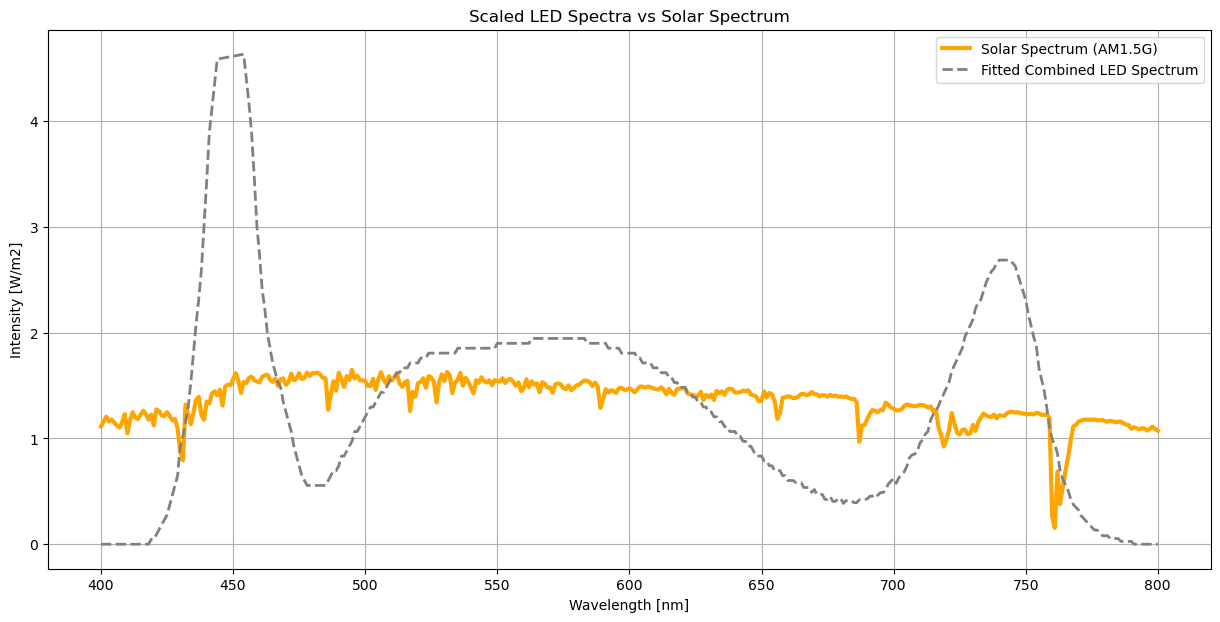

In [4]:
# plot the scaled LED spectra against the solar spectrum
pyplot.figure(figsize=(15,7))
pyplot.plot(df_AM1_5G_filtered['wavelength [nm]'], df_AM1_5G_filtered['power [W/m2]'], label='Solar Spectrum (AM1.5G)', color='orange', linewidth=3)
# for file in LED_spectra.keys():
#     led_interp = numpy.interp(df_AM1_5G_filtered['wavelength [nm]'], LED_spectra[file]['wavelength[nm]'], LED_spectra[file]['relative intensity [%]'])
#     scaled_led = led_interp * optimal_power_scaling[file]
#     pyplot.plot(df_AM1_5G_filtered['wavelength [nm]'], scaled_led, label=f'{file.split(".")[0]} (scaled)', linewidth=2)
pyplot.plot(x_ref, fitted_led_sum, label='Fitted Combined LED Spectrum', color='gray', linestyle='--', linewidth=2) # plot added spectrum
pyplot.title('Scaled LED Spectra vs Solar Spectrum')
pyplot.xlabel('Wavelength [nm]')
pyplot.ylabel('Intensity [W/m2]')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

In [5]:
# integrated irradiance comparison
solar_irradiance = numpy.trapz(df_AM1_5G_filtered['power [W/m2]'], df_AM1_5G_filtered['wavelength [nm]'])
led_irradiance = numpy.trapz(fitted_led_sum, x_ref)

irradiance_error = led_irradiance - solar_irradiance
irradiance_error_pct = 100 * irradiance_error / solar_irradiance

print(f"Solar Irradiance (400-800nm): {solar_irradiance:.2f} W/m2")
print(f"Fitted LED Irradiance (400-800nm): {led_irradiance:.2f} W/m2")
print(f"Irradiance mismatch: {irradiance_error:.2f} W/m2 ({irradiance_error_pct:.2f}%)")

Solar Irradiance (400-800nm): 543.02 W/m2
Fitted LED Irradiance (400-800nm): 537.59 W/m2
Irradiance mismatch: -5.43 W/m2 (-1.00%)


C:\Users\aleja\AppData\Local\Temp\ipykernel_71520\1116410068.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  solar_irradiance = numpy.trapz(df_AM1_5G_filtered['power [W/m2]'], df_AM1_5G_filtered['wavelength [nm]'])
C:\Users\aleja\AppData\Local\Temp\ipykernel_71520\1116410068.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  led_irradiance = numpy.trapz(fitted_led_sum, x_ref)


In [6]:
planck_constant = 6.62607015e-34  # in J·s
speed_of_light = 3e8  # in m/s

df_total_LED = pd.DataFrame({'wavelength[nm]': x_ref})
df_total_LED['power [W/m2]'] = fitted_led_sum

for name, df in LED_spectra.items():
    df['power [W/m2]'] = df['relative intensity [%]'] * optimal_power_scaling[name]
    df['Photon count'] = (df['power [W/m2]'] * df['wavelength [nm]']* 1e-9) / (planck_constant * speed_of_light)

df_total_LED['Photon count'] = (df_total_LED['power [W/m2]'] * df_total_LED['wavelength[nm]']* 1e-9) / (planck_constant * speed_of_light)
df_AM1_5G_filtered['Photon count'] = (df_AM1_5G_filtered['power [W/m2]'] * df_AM1_5G_filtered['wavelength [nm]']* 1e-9) / (planck_constant * speed_of_light)

In [7]:
df_pv_cells = pd.DataFrame(columns=['energy [eV]', 'wavelength [nm]'])

energies = [1.6, 1.7, 1.8, 1.9, 2, 2.4, 2.6, 2.9]
df_pv_cells['energy [eV]'] = energies

df_pv_cells['wavelength [nm]'] = (1239.84193 / df_pv_cells['energy [eV]']).astype(int)

for idx, wavelength in enumerate(df_pv_cells['wavelength [nm]']):
    df_pv_cells.loc[idx, 'solar delivery [W/m2]'] = df_AM1_5G_filtered[df_AM1_5G_filtered['wavelength [nm]'] <= wavelength]['power [W/m2]'].sum()
    df_pv_cells.loc[idx, 'solar delivery [p count]'] = df_AM1_5G_filtered[df_AM1_5G_filtered['wavelength [nm]'] <= wavelength]['Photon count'].sum()
    df_pv_cells.loc[idx, 'SS delivery [W/m2]'] = df_total_LED[df_total_LED['wavelength[nm]'] <= wavelength]['power [W/m2]'].sum()
    df_pv_cells.loc[idx, 'SS delivery [p count]'] = df_total_LED[df_total_LED['wavelength[nm]'] <= wavelength]['Photon count'].sum()

df_pv_cells['ratio [W/m2]'] = df_pv_cells['SS delivery [W/m2]']/df_pv_cells['solar delivery [W/m2]'] -1
df_pv_cells['ratio [p count]'] = df_pv_cells['SS delivery [p count]']/df_pv_cells['solar delivery [p count]'] -1

df_pv_cells = df_pv_cells.loc[df_pv_cells['energy [eV]'] < 2.5]

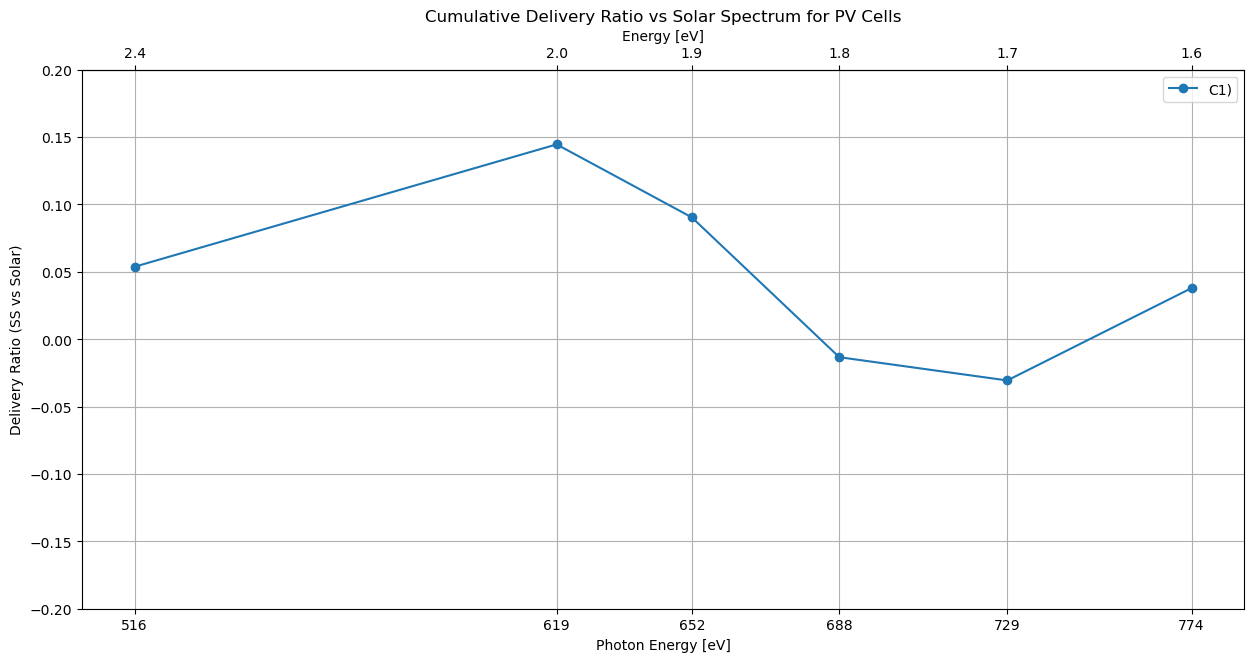

In [47]:
# plot the delivery comparison
fig, ax = pyplot.subplots(figsize=(15,7))
# scaling_factor = 1e-21
# ax.plot(df_pv_cells['wavelength [nm]'], df_pv_cells['solar delivery [p count]'] * scaling_factor, label='AM1.5G', marker='o')
# ax.plot(df_pv_cells['wavelength [nm]'], df_pv_cells['SS delivery [p count]'] * scaling_factor, label='SEMIS', marker='o')
ax.plot(df_pv_cells['wavelength [nm]'], df_pv_cells['ratio [p count]'], label='C1)', marker='o')


# Secondary axis: convert photon energy (eV) <-> wavelength (nm)
def energy_to_wavelength(E_eV):
    E_eV = numpy.asarray(E_eV, dtype=float)
    with numpy.errstate(divide='ignore', invalid='ignore'):
        return 1239.84193 / E_eV

def wavelength_to_energy(lambda_nm):
    lambda_nm = numpy.asarray(lambda_nm, dtype=float)
    with numpy.errstate(divide='ignore', invalid='ignore'):
        return 1239.84193 / lambda_nm

secax = ax.secondary_xaxis('top', functions=(energy_to_wavelength, wavelength_to_energy))
secax.set_xlabel('Energy [eV]')

# Independent wavelength ticks (do not need to align with bottom-axis grid)
secax.set_xticks([1239.84193 / x for x in df_pv_cells['wavelength [nm]']])
secax.set_xticklabels([x for x in df_pv_cells['energy [eV]']])

ax.set_title('Cumulative Delivery Ratio vs Solar Spectrum for PV Cells')
ax.set_xlabel('Photon Energy [eV]')
ax.set_ylabel('Delivery Ratio (SS vs Solar)')
ax.set_xticks(df_pv_cells['wavelength [nm]'])
ax.set_ylim(-0.2, 0.2)
ax.legend()
ax.grid(True)
pyplot.show()

# Additionals

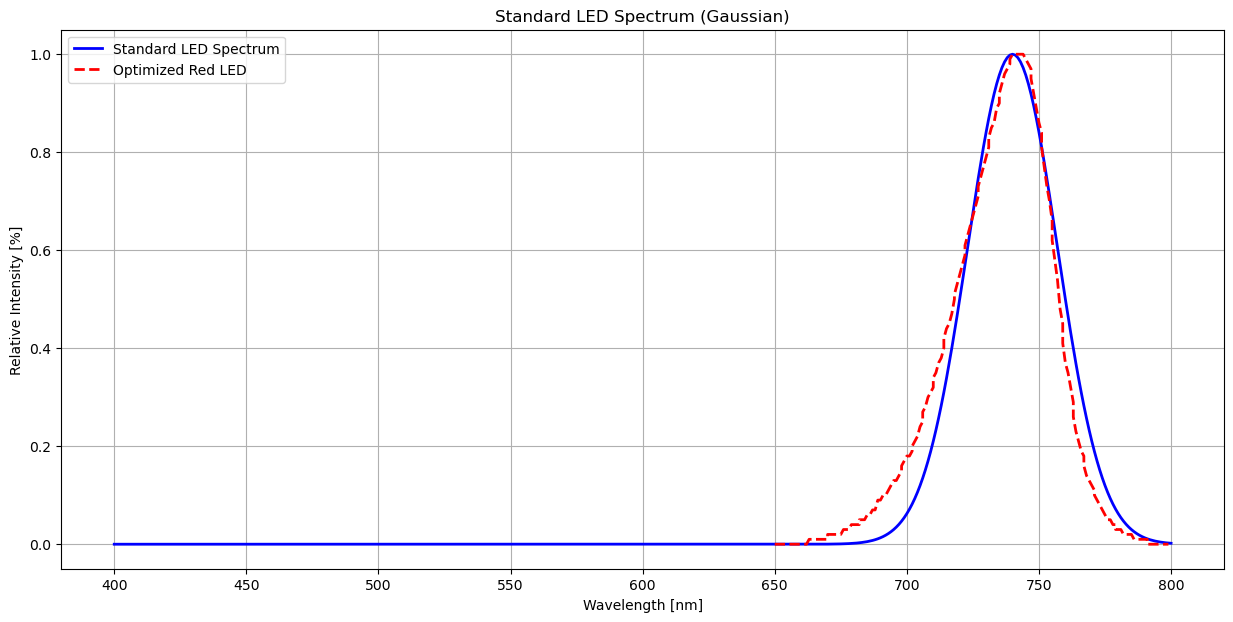

In [16]:
# make a standard LED spectrum depending on the peak wavelength and FWHM of the LED spectra, to be used as a reference for future optimizations
peak_wavelength = 740
fwhm = 40

standard_LED = pd.DataFrame()
standard_LED['wavelength [nm]'] = x_ref
standard_LED['relative intensity [%]'] = 0

def gaussian(x, mu, sigma):
    return numpy.exp(-0.5 * ((x - mu) / sigma) ** 2)

standard_LED['relative intensity [%]'] = gaussian(standard_LED['wavelength [nm]'], peak_wavelength, fwhm / (2 * numpy.sqrt(2 * numpy.log(2)))) * 1

pyplot.figure(figsize=(15,7))
pyplot.plot(standard_LED['wavelength [nm]'], standard_LED['relative intensity [%]'], 
            label='Standard LED Spectrum', color='blue', linewidth=2)
pyplot.plot(LED_spectra['red_740_LED.csv']['wavelength [nm]'], LED_spectra['red_740_LED.csv']['relative intensity [%]'],
            label='Optimized Red LED', color='red', linestyle='--', linewidth=2)
pyplot.title('Standard LED Spectrum (Gaussian)')
pyplot.xlabel('Wavelength [nm]')
pyplot.ylabel('Relative Intensity [%]')
pyplot.legend()
pyplot.grid(True)
pyplot.show()



